# Aufgabe 3_1_4 – Zweipunktregelung mit Hysterese

## Ziel
Erweitern Sie das Modell aus 3_1_4 um eine **Hysterese**, um das ständige Schalten bei Helligkeitswerten nahe am Schwellwert zu vermeiden.

## Modell-Aufbau

| Block | Klasse | Parameter |
|-------|--------|-----------|
| Außenhelligkeit | `Sine` | wie in 3_1_3 |
| Zweipunktregler mit Hysterese | `TwoPointController` | `on_level=200`, `off_level=250` |
| Zeitverlauf-Plot | `Scope` | `t_end=48` |

**Schaltlogik:**
- LED geht **an**, wenn Helligkeit < **200 Lux**  
- LED geht **aus**, wenn Helligkeit > **250 Lux**  
- Zwischen 200 und 250 Lux: **letzter Zustand** bleibt (Hysterese-Bereich = 50 Lux)

In [1]:
import sys
sys.path.insert(0, '..')
from blockdiagram import Sine, TwoPointController, Scope

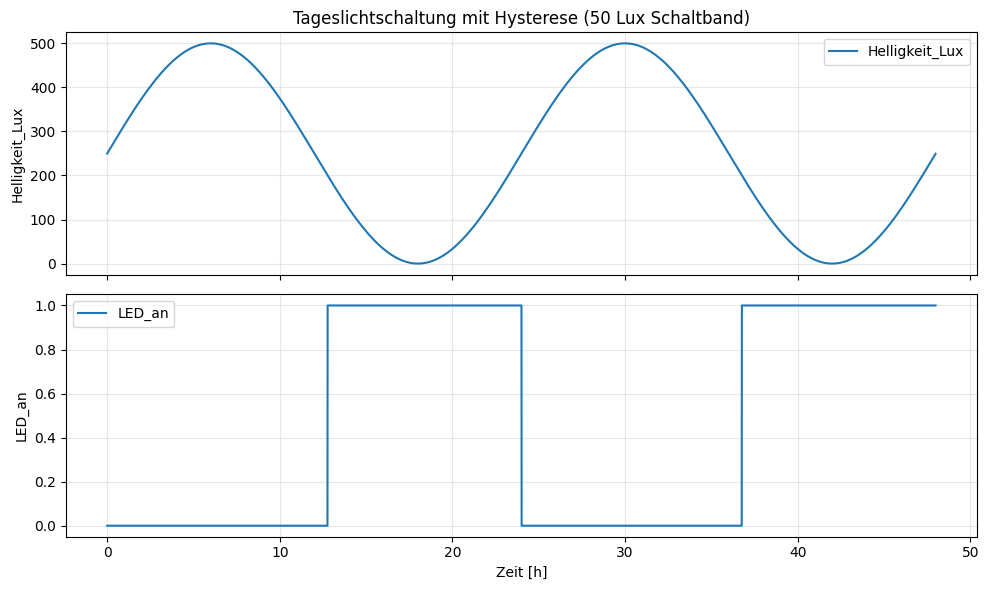

{'Helligkeit_Lux': [np.float64(250.0),
  np.float64(250.6544977218545),
  np.float64(251.3089909578549),
  np.float64(251.96347522217783),
  np.float64(252.61794602906144),
  np.float64(253.27239889283612),
  np.float64(253.92682932795518),
  np.float64(254.5812328490257),
  np.float64(255.23560497083923),
  np.float64(255.88994120840255),
  np.float64(256.5442370769683),
  np.float64(257.1984880920659),
  np.float64(257.85268976953205),
  np.float64(258.50683762554183),
  np.float64(259.16092717663906),
  np.float64(259.8149539397672),
  np.float64(260.4689134322999),
  np.float64(261.1228011720722),
  np.float64(261.77661267741064),
  np.float64(262.43034346716445),
  np.float64(263.083989060736),
  np.float64(263.73754497811143),
  np.float64(264.3910067398918),
  np.float64(265.0443698673234),
  np.float64(265.69762988232833),
  np.float64(266.3507823075358),
  np.float64(267.00382266631203),
  np.float64(267.6567464827917),
  np.float64(268.30954928190795),
  np.float64(268.962226

In [2]:
# Außenhelligkeit
h_aussen = Sine(amplitude=250, offset=250, period=24)

# Zweipunktregler: an bei < 200 Lux, aus bei > 250 Lux
led = TwoPointController(on_level=200, off_level=250, source=h_aussen)

Scope(t_end=48, xlabel="Zeit [h]",
      title="Tageslichtschaltung mit Hysterese (50 Lux Schaltband)").run(
    Helligkeit_Lux=h_aussen,
    LED_an=led
)

## Fragen

**a)** Vergleichen Sie den Schaltverlauf mit Aufgabe 3_1_3 (kein Hysterese-Band): Wie oft schaltet die LED?

*Antwort:*

**b)** Was passiert, wenn das Schaltband sehr groß (z.B. 300 Lux) oder sehr klein (z.B. 5 Lux) gewählt wird?

*Antwort:*

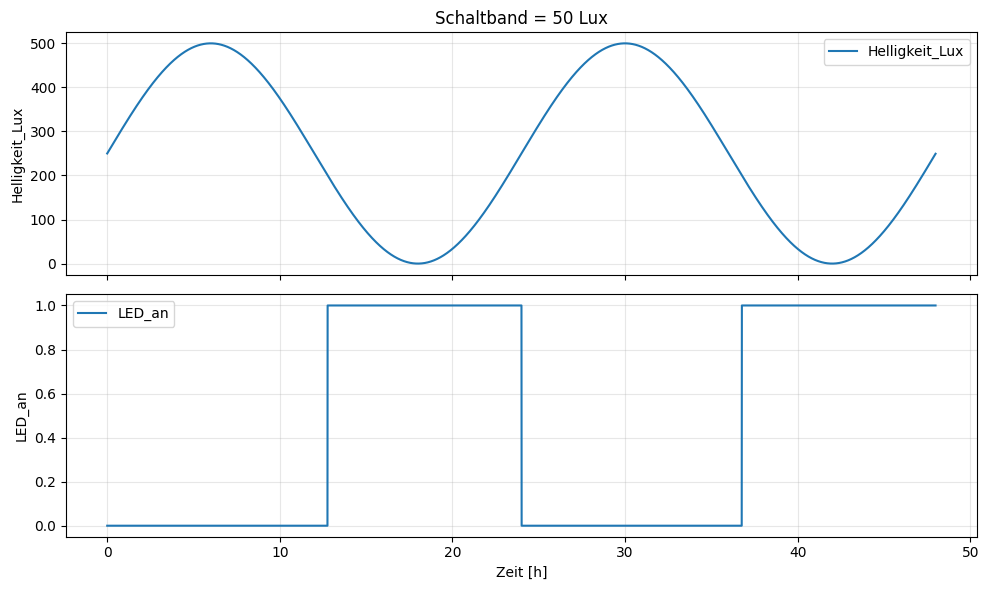

{'Helligkeit_Lux': [np.float64(250.0),
  np.float64(250.6544977218545),
  np.float64(251.3089909578549),
  np.float64(251.96347522217783),
  np.float64(252.61794602906144),
  np.float64(253.27239889283612),
  np.float64(253.92682932795518),
  np.float64(254.5812328490257),
  np.float64(255.23560497083923),
  np.float64(255.88994120840255),
  np.float64(256.5442370769683),
  np.float64(257.1984880920659),
  np.float64(257.85268976953205),
  np.float64(258.50683762554183),
  np.float64(259.16092717663906),
  np.float64(259.8149539397672),
  np.float64(260.4689134322999),
  np.float64(261.1228011720722),
  np.float64(261.77661267741064),
  np.float64(262.43034346716445),
  np.float64(263.083989060736),
  np.float64(263.73754497811143),
  np.float64(264.3910067398918),
  np.float64(265.0443698673234),
  np.float64(265.69762988232833),
  np.float64(266.3507823075358),
  np.float64(267.00382266631203),
  np.float64(267.6567464827917),
  np.float64(268.30954928190795),
  np.float64(268.962226

In [3]:
# Parameterstudie: Schaltband variieren
# on_level < off_level, Schaltband = off_level - on_level

SCHALTBAND = 50   # ← anpassen: 5 / 50 / 300
MITTE = 225       # Mitte des Schaltbandes

on_level  = MITTE - SCHALTBAND / 2
off_level = MITTE + SCHALTBAND / 2

h_aussen = Sine(amplitude=250, offset=250, period=24)
led = TwoPointController(on_level=on_level, off_level=off_level, source=h_aussen)

Scope(t_end=48, xlabel="Zeit [h]",
      title=f"Schaltband = {SCHALTBAND} Lux").run(
    Helligkeit_Lux=h_aussen,
    LED_an=led
)